# CLUSTERING

In [3]:
import pandas as pd
from sqlalchemy import create_engine
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler
from dotenv import load_dotenv
import os 

try:
    import hdbscan
    HDBSCAN_AVAILABLE = True
except ImportError:
    HDBSCAN_AVAILABLE = False
    print("⚠️  hdbscan no instalado. Ejecuta: pip install hdbscan")



In [4]:
# ----------------------------------------------------------
# 2. DATABASE CONFIGURATION
# ----------------------------------------------------------

load_dotenv()

DB_USER = "root"
DB_PASSWORD = os.getenv("ROOT_PASSWORD")
DB_HOST = "localhost"
DB_PORT = int(os.getenv("MYSQL_PORT", "3306"))
DB_NAME = os.getenv("MYSQL_DATABASE")



# ----------------------------------------------------------
# 3. CREATE CONNECTION TO MYSQL
# ----------------------------------------------------------


engine = create_engine(
    f"mysql+mysqlconnector://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

print("Connection to MySQL established successfully.")

Connection to MySQL established successfully.


## 1. EDA

In [5]:
# 2. Cargar la tabla en un DataFrame
df = pd.read_sql("SELECT * FROM erreka_door_behavior_metrics", engine)

# 3. Mostrar los datos
print(df.head())





       door_id  avg_cycles_per_day  peak_usage_cycles  avg_motor_temp  \
0  G-AU-000349                 5.7                8.0            30.9   
1  G-AU-000350                11.7               16.0            30.1   
2  G-AU-000351                11.3               13.0            30.2   
3  G-AU-000352                48.7               52.0            30.4   
4  G-BR-000479                 9.7               14.0            30.8   

   temp_variability  sensor_activation_rate environment     door_type  
0              5.06                   0.000    Domestic  ECOline Home  
1              5.49                   0.000    Domestic  ECOline Home  
2              5.20                   0.000    Domestic  ECOline Home  
3              5.22                   0.002   Community  ECOline Home  
4              5.27                   0.000    Domestic  ECOline Home  


In [6]:
# 1. Guardar el identificador
door_ids = df["door_id"]

# 2. Quitarlo del DataFrame antes de clustering
X = df.drop(columns=["door_id", "environment", "door_type"])

# Apply one-hot encoding to environment and door_type
#X = pd.get_dummies(X, columns=['environment', 'door_type'], drop_first=False)
# 3. Escalar (muy importante antes de clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)




print("Data after transformations:")
print(X.head())
#print("\nNew columns after one-hot encoding:")
#print(X.columns.tolist())

Data after transformations:
   avg_cycles_per_day  peak_usage_cycles  avg_motor_temp  temp_variability  \
0                 5.7                8.0            30.9              5.06   
1                11.7               16.0            30.1              5.49   
2                11.3               13.0            30.2              5.20   
3                48.7               52.0            30.4              5.22   
4                 9.7               14.0            30.8              5.27   

   sensor_activation_rate  
0                   0.000  
1                   0.000  
2                   0.000  
3                   0.002  
4                   0.000  


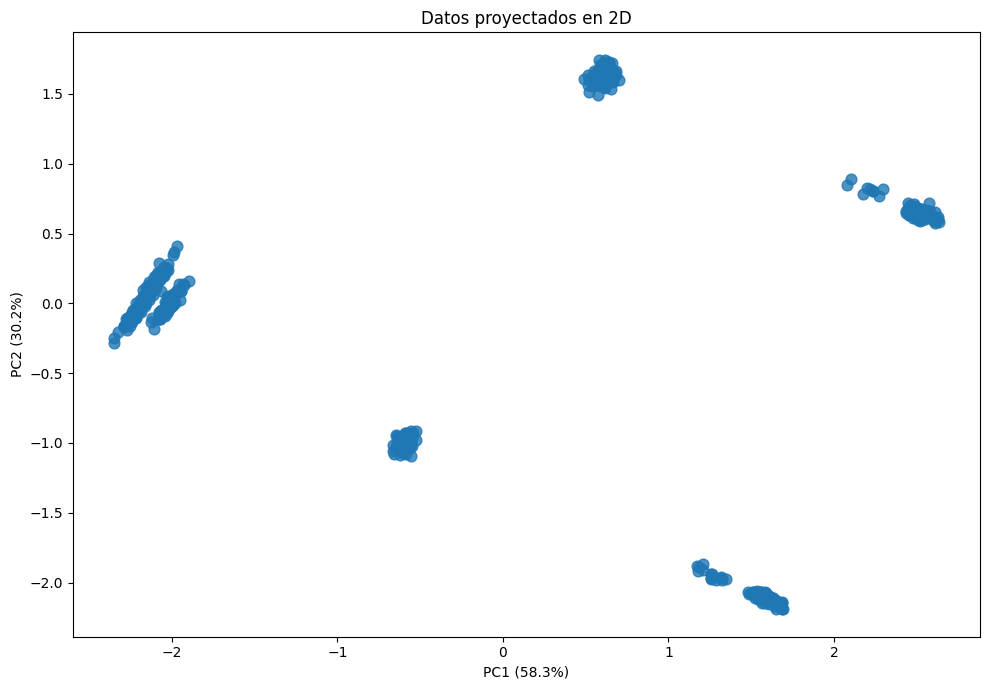

,door_id,avg_cycles_per_day,peak_usage_cycles,avg_motor_temp,temp_variability,sensor_activation_rate,environment,door_type
0,G-AU-000349,5.7,8.0,30.9,5.06,0.000,Domestic,ECOline Home
1,G-AU-000350,11.7,16.0,30.1,5.49,0.000,Domestic,ECOline Home
2,G-AU-000351,11.3,13.0,30.2,5.20,0.000,Domestic,ECOline Home
3,G-AU-000352,48.7,52.0,30.4,5.22,0.002,Community,ECOline Home
4,G-BR-000479,9.7,14.0,30.8,5.27,0.000,Domestic,ECOline Home


In [7]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

plot_df = df.copy().reset_index(drop=True)
features = X_scaled if "X_scaled" in globals() else plot_df.select_dtypes(include="number")
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(features)

plt.figure(figsize=(10, 7))
plt.scatter(coords[:, 0], coords[:, 1], s=60, alpha=0.8)
plt.title("Datos proyectados en 2D")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.tight_layout()
plt.show()

plot_df.head()


## 2. Clustering Models


  CLUSTERING + OPTUNA — Búsqueda de Hiperparámetros

  📦 Datos cargados: 504 muestras, 5 features

═══════════════════════════════════════════════════════
  🔵  KMeans — Optimización con Optuna
═══════════════════════════════════════════════════════
  ✅ Mejores parámetros: {'n_clusters': 5, 'init': 'k-means++', 'max_iter': 495, 'tol': 0.00029187129077219535}
  📊 Silhouette Score:   0.9231

═══════════════════════════════════════════════════════
  🟠  DBSCAN — Optimización con Optuna
═══════════════════════════════════════════════════════
  ✅ Mejores parámetros: {'eps': 0.050309738807851646, 'min_samples': 20}
  📊 Silhouette Score:   0.9799
  🔇 Puntos de ruido:    81.5%
  🔢 Clusters encontrados: 3

═══════════════════════════════════════════════════════
  🟣  HDBSCAN — Optimización con Optuna
═══════════════════════════════════════════════════════
  ✅ Mejores parámetros: {'min_cluster_size': 27, 'min_samples': 7, 'cluster_selection_epsilon': 0.7624722345836591}
  📊 Silhouette Score:   0.9

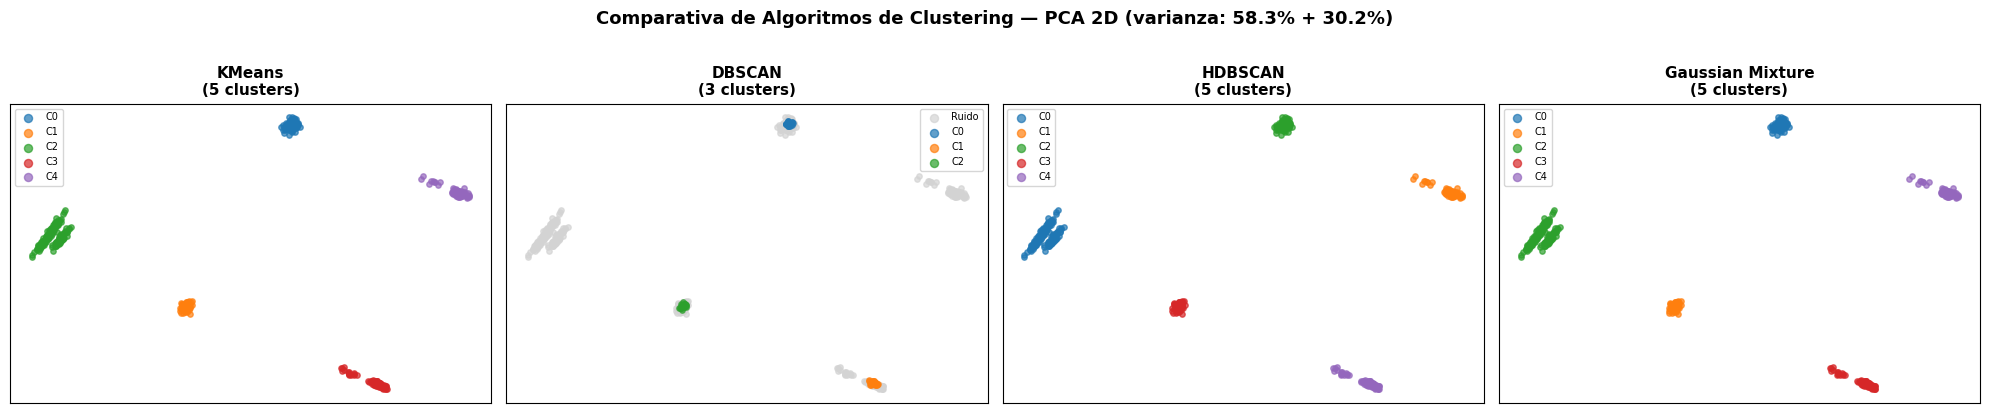


  💾 Gráfica guardada: clustering_comparativa.png


In [8]:
"""
=========================================================
  Clustering con Optuna - Optimización de Hiperparámetros
  KMeans | DBSCAN | HDBSCAN | Gaussian Mixture
=========================================================

"""

# ─────────────────────────────────────────────
#  FUNCIÓN DE EVALUACIÓN (multi-métrica)
# ─────────────────────────────────────────────
def evaluate_clustering(X, labels):
    """
    Evalúa la calidad del clustering con múltiples métricas.
    Devuelve None si el clustering no es válido.
    """
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Necesitamos al menos 2 clusters y no todos los puntos en ruido
    if n_clusters < 2:
        return None

    # Filtramos puntos de ruido (-1) para las métricas
    mask = labels != -1
    if mask.sum() < 2 * n_clusters:
        return None

    X_valid = X[mask]
    labels_valid = labels[mask]

    # Silhouette: [-1, 1], mayor es mejor
    sil = silhouette_score(X_valid, labels_valid)
    return sil


# ═══════════════════════════════════════════════════════
#  1. KMEANS
# ═══════════════════════════════════════════════════════
def optimize_kmeans(X, n_trials=50):
    print("\n" + "═"*55)
    print("  🔵  KMeans — Optimización con Optuna")
    print("═"*55)

    def objective(trial):
        n_clusters = trial.suggest_int("n_clusters", 2, 15)
        init       = trial.suggest_categorical("init", ["k-means++", "random"])
        max_iter   = trial.suggest_int("max_iter", 100, 500)
        tol        = trial.suggest_float("tol", 1e-5, 1e-2, log=True)

        model = KMeans(
            n_clusters=n_clusters,
            init=init,
            max_iter=max_iter,
            tol=tol,
            n_init=10,
            random_state=42
        )
        labels = model.fit_predict(X)
        score = evaluate_clustering(X, labels)
        return score if score is not None else -1

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    best = study.best_params
    print(f"  ✅ Mejores parámetros: {best}")
    print(f"  📊 Silhouette Score:   {study.best_value:.4f}")

    # Ajustar modelo final
    model = KMeans(
        n_clusters=best["n_clusters"],
        init=best["init"],
        max_iter=best["max_iter"],
        tol=best["tol"],
        n_init=10,
        random_state=42
    )
    labels = model.fit_predict(X)
    return labels, study, model


# ═══════════════════════════════════════════════════════
#  2. DBSCAN
# ═══════════════════════════════════════════════════════
def optimize_dbscan(X, n_trials=80):
    print("\n" + "═"*55)
    print("  🟠  DBSCAN — Optimización con Optuna")
    print("═"*55)

    def objective(trial):
        eps         = trial.suggest_float("eps", 0.05, 3.0)
        min_samples = trial.suggest_int("min_samples", 2, 20)

        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(X)
        score = evaluate_clustering(X, labels)
        return score if score is not None else -1

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    best = study.best_params
    noise_pct = None

    print(f"  ✅ Mejores parámetros: {best}")
    print(f"  📊 Silhouette Score:   {study.best_value:.4f}")

    # Ajustar modelo final
    #model = DBSCAN(eps=0.8, min_samples=10) #after analyzing best results these are actually the best hyperparmeters.

    model = DBSCAN(eps=best["eps"], min_samples=best["min_samples"])
    labels = model.fit_predict(X)
    noise_pct = (labels == -1).sum() / len(labels) * 100
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"  🔇 Puntos de ruido:    {noise_pct:.1f}%")
    print(f"  🔢 Clusters encontrados: {n_clusters}")
    return labels, study, model


# ═══════════════════════════════════════════════════════
#  3. HDBSCAN
# ═══════════════════════════════════════════════════════
def optimize_hdbscan(X, n_trials=60):
    print("\n" + "═"*55)
    print("  🟣  HDBSCAN — Optimización con Optuna")
    print("═"*55)

    if not HDBSCAN_AVAILABLE:
        print("  ❌ hdbscan no disponible. Instala con: pip install hdbscan")
        return None, None, None

    def objective(trial):
        min_cluster_size = trial.suggest_int("min_cluster_size", 5, 50)
        min_samples      = trial.suggest_int("min_samples", 1, 20)
        cluster_selection_epsilon = trial.suggest_float(
            "cluster_selection_epsilon", 0.0, 1.0
        )

        model = hdbscan.HDBSCAN(
            min_cluster_size=min_cluster_size,
            min_samples=min_samples,
            cluster_selection_epsilon=cluster_selection_epsilon,
        )
        labels = model.fit_predict(X)
        score = evaluate_clustering(X, labels)
        return score if score is not None else -1

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    best = study.best_params
    print(f"  ✅ Mejores parámetros: {best}")
    print(f"  📊 Silhouette Score:   {study.best_value:.4f}")

    model = hdbscan.HDBSCAN(
        min_cluster_size=best["min_cluster_size"],
        min_samples=best["min_samples"],
        cluster_selection_epsilon=best["cluster_selection_epsilon"],
    )
    labels = model.fit_predict(X)
    noise_pct = (labels == -1).sum() / len(labels) * 100
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"  🔇 Puntos de ruido:    {noise_pct:.1f}%")
    print(f"  🔢 Clusters encontrados: {n_clusters}")
    return labels, study, model


# ═══════════════════════════════════════════════════════
#  4. GAUSSIAN MIXTURE MODEL (GMM)
# ═══════════════════════════════════════════════════════
def optimize_gmm(X, n_trials=60):
    print("\n" + "═"*55)
    print("  🟢  Gaussian Mixture — Optimización con Optuna")
    print("═"*55)

    def objective(trial):
        n_components    = trial.suggest_int("n_components", 2, 15)
        covariance_type = trial.suggest_categorical(
            "covariance_type", ["full", "tied", "diag", "spherical"]
        )
        max_iter = trial.suggest_int("max_iter", 100, 500)
        tol      = trial.suggest_float("tol", 1e-5, 1e-2, log=True)

        try:
            model = GaussianMixture(
                n_components=n_components,
                covariance_type=covariance_type,
                max_iter=max_iter,
                tol=tol,
                random_state=42
            )
            model.fit(X)
            labels = model.predict(X)
            score = evaluate_clustering(X, labels)
            return score if score is not None else -1
        except Exception:
            return -1

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    best = study.best_params
    print(f"  ✅ Mejores parámetros: {best}")
    print(f"  📊 Silhouette Score:   {study.best_value:.4f}")

    model = GaussianMixture(
        n_components=best["n_components"],
        covariance_type=best["covariance_type"],
        max_iter=best["max_iter"],
        tol=best["tol"],
        random_state=42
    )
    model.fit(X)
    labels = model.predict(X)
    return labels, study, model


# ═══════════════════════════════════════════════════════
#  COMPARATIVA FINAL
# ═══════════════════════════════════════════════════════
def compare_results(X, results):
    """Tabla comparativa de todos los modelos."""
    print("\n" + "═"*65)
    print("  📋  COMPARATIVA FINAL DE MODELOS")
    print("═"*65)
    print(f"  {'Modelo':<20} {'Clusters':>8} {'Silhouette':>12} {'Davies-B':>10} {'Calinski':>10}")
    print("  " + "─"*63)

    rows = []
    for name, labels in results.items():
        if labels is None:
            continue
        mask = labels != -1
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters < 2 or mask.sum() < 4:
            print(f"  {name:<20} {'N/A':>8}")
            continue

        X_v, l_v = X[mask], labels[mask]
        sil  = silhouette_score(X_v, l_v)
        db   = davies_bouldin_score(X_v, l_v)
        ch   = calinski_harabasz_score(X_v, l_v)
        rows.append((name, n_clusters, sil, db, ch))
        print(f"  {name:<20} {n_clusters:>8} {sil:>12.4f} {db:>10.4f} {ch:>10.1f}")

    print("═"*65)
    if rows:
        best = max(rows, key=lambda x: x[2])
        print(f"\n  🏆 Mejor modelo (Silhouette): {best[0]}  ({best[2]:.4f})")


# ═══════════════════════════════════════════════════════
#  VISUALIZACIÓN
# ═══════════════════════════════════════════════════════
def plot_results(X, results):
    """Gráficas lado a lado de todos los métodos usando PCA."""
    pca = PCA(n_components=2, random_state=42)
    X_2d = pca.fit_transform(X)

    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 4))
    if n == 1:
        axes = [axes]

    colors_map = plt.cm.tab10

    for ax, (name, labels) in zip(axes, results.items()):
        if labels is None:
            ax.set_title(f"{name}\n(no disponible)")
            ax.axis("off")
            continue

        unique = sorted(set(labels))
        for k in unique:
            mask = labels == k
            color = "lightgray" if k == -1 else colors_map(k % 10)
            label = "Ruido" if k == -1 else f"C{k}"
            ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=[color], s=15,
                       alpha=0.7, label=label)

        n_clusters = len(unique) - (1 if -1 in unique else 0)
        ax.set_title(f"{name}\n({n_clusters} clusters)", fontsize=11, fontweight="bold")
        ax.legend(fontsize=7, markerscale=1.5)
        ax.set_xticks([])
        ax.set_yticks([])

    plt.suptitle(
        f"Comparativa de Algoritmos de Clustering — PCA 2D (varianza: {pca.explained_variance_ratio_[0]:.1%} + {pca.explained_variance_ratio_[1]:.1%})",
        fontsize=13,
        fontweight="bold",
        y=1.02,
    )
    plt.tight_layout()
    plt.savefig("clustering_comparativa.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("\n  💾 Gráfica guardada: clustering_comparativa.png")


# ─────────────────────────────────────────────
#  MAIN
# ─────────────────────────────────────────────
if __name__ == "__main__":
    print("\n" + "="*55)
    print("  CLUSTERING + OPTUNA — Búsqueda de Hiperparámetros")
    print("="*55)


    print(f"\n  📦 Datos cargados: {X_scaled.shape[0]} muestras, {X_scaled.shape[1]} features")

    # 2. Optimizar cada algoritmo
    labels_km,  study_km,  model_km  = optimize_kmeans(X_scaled,  n_trials=50)
    labels_db,  study_db,  model_db  = optimize_dbscan(X_scaled,  n_trials=80)
    labels_hdb, study_hdb, model_hdb = optimize_hdbscan(X_scaled, n_trials=60)
    labels_gmm, study_gmm, model_gmm = optimize_gmm(X_scaled,    n_trials=60)

    from scipy.spatial.distance import euclidean
    # Supongamos que 'X_original' son tus datos con todas las dimensiones (antes del PCA)
    # y 'labels' son las etiquetas que te dio HDBSCAN o KMeans

    # 1. Sacamos los puntos del cluster 0 (Azul) y cluster 1 (Naranja)
    puntos_c0 = X[labels_db == 0]
    puntos_c1 = X[labels_db == 1]

    # 2. Calculamos el "centro" de cada cluster en el espacio original
    centroide_c0 = puntos_c0.mean(axis=0)
    centroide_c1 = puntos_c1.mean(axis=0)

    # 3. Medimos la distancia real
    distancia_real = euclidean(centroide_c0, centroide_c1)
    print(f"Distancia real en N-dimensiones: {distancia_real}")
      
    # 3. Comparar
    results = {
        "KMeans":           labels_km,
        "DBSCAN":           labels_db,
        "HDBSCAN":          labels_hdb,
        "Gaussian Mixture": labels_gmm,
    }
    compare_results(X_scaled, results)

    # 4. Visualizar
    plot_results(X_scaled, results)

### Kmeans, hdbscan and gaussian mixture give equal results. However I will choose Gaussian Mixture, since it may be the best for the future because of these reasons: 
1. The number of clusters (based on doors behaviour) will not change in the future, or if they change it will be because the creation of a new door, so we know the exact number of clusters (6).
2. Computationaly scalable
3. No need of density based clustering since the groups have similar density. 
4. Kmeans assumes the clusters have spherical shapes, gaussian mixture no. 
5. Can give information of the probability of each individual to each cluster. 

In [9]:
# Unir door_id + datos originales + etiquetas de clustering
clustered_df = df.copy()
clustered_df["door_id"] = door_ids.values

label_sources = {
    "cluster_kmeans": "labels_km",
    "cluster_dbscan": "labels_db",
    "cluster_hdbscan": "labels_hdb",
    "cluster_gmm": "labels_gmm",
}

for col_name, var_name in label_sources.items():
    labels = globals().get(var_name)
    if labels is not None and len(labels) == len(clustered_df):
        clustered_df[col_name] = labels

print("Columnas disponibles en clustered_df:")
print(clustered_df.columns.tolist())
display(clustered_df.head())


# Opcional: guardar resultado completo para análisis externo
# clustered_df.to_csv("doors_with_clusters.csv", index=False)

Columnas disponibles en clustered_df:
['door_id', 'avg_cycles_per_day', 'peak_usage_cycles', 'avg_motor_temp', 'temp_variability', 'sensor_activation_rate', 'environment', 'door_type', 'cluster_kmeans', 'cluster_dbscan', 'cluster_hdbscan', 'cluster_gmm']


,door_id,avg_cycles_per_day,peak_usage_cycles,avg_motor_temp,temp_variability,sensor_activation_rate,environment,door_type,cluster_kmeans,cluster_dbscan,cluster_hdbscan,cluster_gmm
0,G-AU-000349,5.7,8.0,30.9,5.06,0.000,Domestic,ECOline Home,2,-1,0,2
1,G-AU-000350,11.7,16.0,30.1,5.49,0.000,Domestic,ECOline Home,2,-1,0,2
2,G-AU-000351,11.3,13.0,30.2,5.20,0.000,Domestic,ECOline Home,2,-1,0,2
3,G-AU-000352,48.7,52.0,30.4,5.22,0.002,Community,ECOline Home,2,-1,0,2
4,G-BR-000479,9.7,14.0,30.8,5.27,0.000,Domestic,ECOline Home,2,-1,0,2


## Interpretating each cluster

In [10]:
# Resumen por cluster usando solo KMeans:
# 1) media para columnas numéricas
# 2) valor más frecuente (moda) para columnas string
exclude_cols = ["cluster_kmeans", "cluster_hdbscan", "cluster_dbscan"]
base_df = clustered_df.drop(columns=exclude_cols, errors="ignore")

numeric_cols = base_df.select_dtypes(include="number").columns.drop("cluster_gmm", errors="ignore")
string_cols = base_df.select_dtypes(include=["object", "string", "category"]).columns

gaussianMixture_numeric_means = base_df.groupby("cluster_gmm")[numeric_cols].mean().round(3)
gaussianMixture_string_modes = base_df.groupby("cluster_gmm")[string_cols].agg(
    lambda s: s.mode().iloc[0] if not s.mode().empty else pd.NA
)

kmeans_cluster_summary = pd.concat([gaussianMixture_numeric_means, gaussianMixture_string_modes], axis=1)
display(kmeans_cluster_summary)


,avg_cycles_per_day,peak_usage_cycles,avg_motor_temp,temp_variability,sensor_activation_rate,door_id,environment,door_type
cluster_gmm,,,,,,,,
0,196.435,208.991,47.004,7.217,0.206,I-AU-000346,Standard Dock,ROLLfast Industrial 300
1,119.515,130.206,36.501,5.181,0.526,P-AU-000343,Office,ECOline Pedestrian
2,22.331,25.982,30.466,5.212,0.000,G-AU-000349,Domestic,ECOline Home
3,762.051,825.181,36.505,5.188,0.526,P-AU-000344,Retail/Hospital,ECOline Pedestrian
4,774.582,821.455,47.013,7.220,0.205,I-AU-000348,High Speed Door,ROLLfast Industrial 300


## Load corresponding labels to each door in the data base 

In [11]:
from sqlalchemy import text

# Cargar solo las etiquetas de KMeans en la tabla de la base de datos
kmeans_labels_df = pd.DataFrame({
    "door_id": door_ids.values,
    "cluster_gmm": labels_gmm,
})

with engine.begin() as connection:
    # Crear la columna si no existe
    columns_df = pd.read_sql(
        text("""
            SELECT COLUMN_NAME
            FROM INFORMATION_SCHEMA.COLUMNS
            WHERE TABLE_SCHEMA = :schema
              AND TABLE_NAME = :table_name
              AND COLUMN_NAME = 'cluster_gmm'
        """),
        connection,
        params={"schema": DB_NAME, "table_name": "erreka_door_behavior_metrics"},
    )

    if columns_df.empty:
        connection.execute(
            text("ALTER TABLE erreka_door_behavior_metrics ADD COLUMN cluster_gmm INT")
        )

    # Actualizar una fila por puerta con su label de gaussian mixture
    for door_id, cluster_kmeans in kmeans_labels_df.itertuples(index=False):
        connection.execute(
            text("""
                UPDATE erreka_door_behavior_metrics
                SET cluster_gmm = :cluster_gmm
                WHERE door_id = :door_id
            """),
            {"door_id": door_id, "cluster_gmm": int(cluster_kmeans)},
        )

print("Tabla erreka_door_behavior_metrics actualizada con cluster_gmm.")


Tabla erreka_door_behavior_metrics actualizada con cluster_gmm.
